In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import os
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import copy
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score,classification_report,ConfusionMatrixDisplay

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as transforms
import torchaudio.transforms as T

from torch.utils.data import Dataset,DataLoader

from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
SR = 22050
DURATION = 30

from kaggle_secrets import UserSecretsClient
user_secrets = UserSecretsClient()
secret_value_0 = user_secrets.get_secret("kgg_key")
secret_value_1 = user_secrets.get_secret("kgg_user")
secret_value_2 = user_secrets.get_secret("WANDB_API_KEY")


#============ Check for GPU availability ==============================#
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🚀 Using device: {device}")

RANDOM_SEED = 42
torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
if torch.cuda.is_available():
    print("GPU is available.Setting RANDOM_SEED .... ")
        # setting for both CPU and GPU
    torch.cuda.manual_seed_all(RANDOM_SEED)
    print(f"   GPU: {torch.cuda.get_device_name(0)}")
    print(f"   Memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")
else:
    print("   Running on CPU")
print("\n✅ Environment setup complete!")

import warnings
warnings.filterwarnings("ignore")

🚀 Using device: cuda
GPU is available.Setting RANDOM_SEED .... 
   GPU: Tesla T4
   Memory: 14.6 GB

✅ Environment setup complete!


First Neural Network & CNNs!

* Learn PyTorch basics: Tensors, Dataset (custom loader for training), DataLoader.
* Convert audio to 2D/1D Mel-Spectrograms.
* Build a simple CNN (Convolutional Neural Network)/NN (Neural Network) to process the spectrograms.
* Implement training loop, loss, optimizer, and wandb logging.
* Train and evaluate your CNN/NN (Neural Network)model.

# Definition

## - Utility

In [2]:
def extract_paths(pc=15000,test_size=0.2):
    GENRES = ['blues', 'classical', 'country', 'disco', 'hiphop','jazz', 'metal', 'pop', 'reggae', 'rock'] 
    train_paths = []
    val_paths = []
    count = 0
    tr_count = 0
    val_count = 0
    
    paths_count = pc
    test_size = paths_count*test_size
    train_size = paths_count - test_size
    
    for g in GENRES:
        root_dir_path = f"/kaggle/input/datasets/akashkumbhakar/{g}-mel-15000"
        for i in range(0,paths_count):
            file_name = f"mashup_{i}.wav.npy"
            path = os.path.join(root_dir_path,file_name)
            if i >= train_size:
                val_paths.append((path,g))
                val_count += 1
            else : 
                train_paths.append((path,g))
                tr_count += 1
            count += 1
    print("Total paths (music files) : ", count)
    print("Total training files : ", tr_count)
    print("Total validation files : ", val_count)
    return train_paths,val_paths

def check_split():
    GENRES = ['blues', 'classical', 'country', 'disco', 'hiphop','jazz', 'metal', 'pop', 'reggae', 'rock'] 
    g_c = {}
    for i in tr:
        if i[1] in g_c.keys():
            g_c[i[1]] += 1
        else:
            g_c[i[1]] = 1
    return g_c

def genre_to_idx(str_label):
    genre_to_id = {'blues':0, 'classical':1, 'country':2, 'disco':3, 'hiphop':4,'jazz':5, 'metal':6, 'pop':7, 'reggae':8, 'rock':9}
    y = genre_to_id[str_label]

    return y

def idx_to_genre(targets):
    id_to_genre = {0:'blues', 1:'classical', 2:'country', 3:'disco', 4:'hiphop',5:'jazz', 6:'metal', 7:'pop', 8:'reggae', 9:'rock'}
    y = [id_to_genre[id] for id in targets]

    return y    

## - Dataset and DataLoader

In [3]:
class MelDataset(Dataset):
    def __init__(self,paths,transform):  # paths : List[(path,label)]
        self.paths = paths
        self.transform = transform
    def __len__(self):
        return len(self.paths)
    def __getitem__(self,idx):
        mel = np.load(self.paths[idx][0])
        label = genre_to_idx(self.paths[idx][1])
        #mel = torch.from_numpy(mel).float()
        mel = self.transform(mel)
        label = torch.tensor(label, dtype=torch.long)
        return mel,label

data_transformer = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[-45.60], std=[16.60]),
    T.FrequencyMasking(freq_mask_param=8),
    T.TimeMasking(time_mask_param=20)
])

## - Coonfig

In [4]:
config = {
    "model_name" : "clstm",
    "version" : 'v2',
    "batch_size" : 64,
    "lr" : 0.0001,
    "sample_count" : 0,
    "epochs" : 20,
    "log_wandb" : False,
    "description" : None
}

try:
    dir_path = f"/kaggle/working/{config['model_name']}"
    os.makedirs(dir_path, exist_ok=True)
    print(f"Directory created at: {dir_path}")
except Exception as e:
    print(f"Error creating directory: {e}")

Directory created at: /kaggle/working/clstm


In [5]:
train_paths,val_paths = extract_paths(pc=15000)

train_dataset = MelDataset(train_paths,data_transformer)
train_loader = DataLoader(
    train_dataset,
    batch_size=config['batch_size'],
    shuffle=True,
    num_workers=4,
    persistent_workers=True,
    pin_memory=True
)
val_dataset = MelDataset(val_paths,data_transformer)
val_loader = DataLoader(
    val_dataset,
    batch_size=config['batch_size'],
    shuffle=True,
    num_workers=4,
    persistent_workers=True,
    pin_memory=True
)
config['sample_count'] = len(train_paths)
print(f"✅ BATCH SIZE : {config['batch_size']} | Size of Train Dataloader : {len(train_loader)}  |  Size of Val Dataloader : {len(val_loader)}")

Total paths (music files) :  150000
Total training files :  120000
Total validation files :  30000
✅ BATCH SIZE : 64 | Size of Train Dataloader : 1875  |  Size of Val Dataloader : 469


## - Model

In [6]:
class MelCLSTM(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        #self.cnn =  nn.Sequential()
        # First convolutional block
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(16)
        self.pool1 = nn.MaxPool2d(2,2)
        
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(32)
        self.pool2 = nn.MaxPool2d(2,2)
        
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(64)
        self.pool3 = nn.MaxPool2d(2,2)


        #self.global_pool = nn.AdaptiveAvgPool2d((1,1))
        # Fully connected head
        #self.fc1 = nn.Linear(64, 128)
        #self.dropout = nn.Dropout(0.5)
        #self.fc2 = nn.Linear(128, num_classes)
        self.lstm = nn.LSTM(
            1024,
            hidden_size=64,
            batch_first=True,
            num_layers=1,
            bidirectional=True
        )
        self.fc = nn.Linear(64*2, num_classes)

    def forward(self, x):

        # INPUT :  (B,1,128,647)

        x = self.pool1(F.relu(self.bn1(self.conv1(x))))  
        x = self.pool2(F.relu(self.bn2(self.conv2(x))))
        x = self.pool3(F.relu(self.bn3(self.conv3(x))))
        #SHAPE Here : (B,64,16,80)
        #x = self.global_pool(x)
        #x = x.view(x.size(0), -1)
        #x = F.relu(self.fc1(x))
        #x = self.dropout(x)
        #x = self.fc2(x)
        batch,channel,freq,time = x.size()
        #print(batch,channel,freq,time)
        x_rnn_in = x.permute(0, 3, 1, 2).reshape(batch,time,channel*freq)
        x_rnn_out, _hc= self.lstm(x_rnn_in)
        pooled_x,_ = torch.max(x_rnn_out, dim=1)
        out_logit = self.fc(pooled_x)        
        return out_logit

model = MelCLSTM(10)
grad_param_count = 0
total_pram_count = 0
for name,p in model.named_parameters():
    mark = ""
    total_pram_count += p.numel()
    if p.requires_grad:
        mark = "[RG]" # [RG] for gradient computation
        grad_param_count += p.numel()
    print(mark," ",name," - ",p.size()," - ",p.numel())

print(f"\nTotal Parameter : {total_pram_count}\nParameters with Gradient : {grad_param_count}")

[RG]   conv1.weight  -  torch.Size([16, 1, 3, 3])  -  144
[RG]   conv1.bias  -  torch.Size([16])  -  16
[RG]   bn1.weight  -  torch.Size([16])  -  16
[RG]   bn1.bias  -  torch.Size([16])  -  16
[RG]   conv2.weight  -  torch.Size([32, 16, 3, 3])  -  4608
[RG]   conv2.bias  -  torch.Size([32])  -  32
[RG]   bn2.weight  -  torch.Size([32])  -  32
[RG]   bn2.bias  -  torch.Size([32])  -  32
[RG]   conv3.weight  -  torch.Size([64, 32, 3, 3])  -  18432
[RG]   conv3.bias  -  torch.Size([64])  -  64
[RG]   bn3.weight  -  torch.Size([64])  -  64
[RG]   bn3.bias  -  torch.Size([64])  -  64
[RG]   lstm.weight_ih_l0  -  torch.Size([256, 1024])  -  262144
[RG]   lstm.weight_hh_l0  -  torch.Size([256, 64])  -  16384
[RG]   lstm.bias_ih_l0  -  torch.Size([256])  -  256
[RG]   lstm.bias_hh_l0  -  torch.Size([256])  -  256
[RG]   lstm.weight_ih_l0_reverse  -  torch.Size([256, 1024])  -  262144
[RG]   lstm.weight_hh_l0_reverse  -  torch.Size([256, 64])  -  16384
[RG]   lstm.bias_ih_l0_reverse  -  torch.

In [7]:
model

MelCLSTM(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (lstm): LSTM(1024, 64, batch_first=True, bidirectional=True)
  (fc): Linear(in_features=128, out_features=10, bias=True)
)

## - Training

In [9]:
def train(model,train_loader,val_loader,loss_fn, optimizer,config):
    train_loss = []
    train_f1_score = []
    max_f1 = 0.0
    best_model_state = None
    best_optim_state = None
    best_train_loss = None
    best_val_loss = None
    model.train()

    # initialization of wandb
    log_wandb = config["log_wandb"]
    run = None
    if log_wandb:
        run = wandb.init(
            entity="23f1001065-indian-institute-of-technology-madras",
            project="23f1001065-t12026",
            name=config['run_name'],
            config = config
        )
    num_epochs = config['epochs']
    for epoch in range(num_epochs):
        running_loss = 0.0
        progress_bar = tqdm(enumerate(train_loader), total=len(train_loader),desc=f"Epoch {epoch+1}/{num_epochs}")
        for i,(mels,labels) in progress_bar:
            mels , labels = mels.to(device,non_blocking=True), labels.to(device,non_blocking=True)
            optimizer.zero_grad()
            
            outputs = model(mels)
            loss = loss_fn(outputs, labels)
        
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            avg_loss = running_loss / (i + 1)

            progress_bar.set_postfix({
                'loss': f"{avg_loss:.4f}"
            })
        loss = running_loss / len(train_loader)
        t,p,f1score,val_loss = validation(model,val_loader,criterion)
        print(f"Train Loss: {loss:.4f}")
        # Upload metrics
        if run:
            run.log({
                "train_loss" : float(loss),
                "val_loss" : float(val_loss),
                "f1_score" : float(f1score)
            })
        if f1score > max_f1 + 0.001 :
            max_f1 = f1score
            best_train_loss = loss
            best_val_loss = val_loss
            best_model_state = copy.deepcopy(model.state_dict())
            best_optim_state = copy.deepcopy(optimizer.state_dict())
    # Close Wandb
    if run:
        run.finish()
    return (best_model_state,
            best_optim_state,
            best_train_loss,
            best_val_loss,
            max_f1)


## - Evaluation

In [10]:
def validation(model,val_loader,loss_fn):
    model.eval()
    val_loss = 0.0
    all_true = []
    all_pred = []
    with torch.no_grad():
        progress_bar = tqdm(enumerate(val_loader), total=len(val_loader),desc=f"Validation")
        for i,(mels,labels) in progress_bar:
            mels,labels = mels.to(device,non_blocking=True),labels.to(device,non_blocking=True)
            output = model(mels)
            loss = loss_fn(output,labels)

            probs = torch.softmax(output,dim=1) 
            predicted_y = torch.argmax(probs,dim=1)
            
            val_loss += loss.item()
            avg_loss = val_loss / (i + 1)

            progress_bar.set_postfix({
                'loss': f"{avg_loss:.4f}"
            })

            all_true.extend(labels.cpu().numpy())
            all_pred.extend(predicted_y.cpu().numpy())
        #all_true = torch.cat(all_true,dim=0)
        #all_pred = torch.cat(all_pred,dim=0).cpu().numpy()
        #print(len(all_true),len(all_pred))
    
        loss = val_loss/len(val_loader)
        f1score = f1_score(all_true,all_pred,average='macro')

        print(f"Validation Loss : {loss},  F1_score : {f1score}")
        model.train()
        return all_true,all_pred,f1score,loss
            

# Wandb login

In [11]:
while True:
    choice = input("Dou you want to log at WanDb[YES/NO] ?")
    if choice in ['YES','NO']:
        break
    else:
        print("Invalid input : Please enter 'YES' or 'NO'.")
if choice == 'YES':
    config["log_wandb"] = True
    print("Continuing....")
    import wandb
    print(f"Wandb version: {wandb.__version__}")
    wandb.login(key=secret_value_2)
else:
    config["log_wandb"] = False
    print("Aborting.")

Dou you want to log at WanDb[YES/NO] ? YES


Continuing....
Wandb version: 0.24.0


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: 23f1001065 (23f1001065-indian-institute-of-technology-madras) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


# Training

## - Setup

In [12]:
model = MelCLSTM(10).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=config['lr'])

run_name = "-".join([str(attribute) for attribute in list(config.values())[:6]])
config['run_name'] = run_name

config

{'model_name': 'clstm',
 'version': 'v2',
 'batch_size': 64,
 'lr': 0.0001,
 'sample_count': 120000,
 'epochs': 20,
 'log_wandb': True,
 'description': None,
 'run_name': 'clstm-v2-64-0.0001-120000-20'}

## - Training loop execution

In [13]:
print(run_name)
best_model_state,best_optim_state,train_loss,val_loss,f1 = train(model,train_loader,val_loader,criterion, optimizer,config)

clstm-v2-64-0.0001-120000-20


Epoch 1/20:   0%|          | 0/1875 [00:00<?, ?it/s]

Validation:   0%|          | 0/469 [00:00<?, ?it/s]

Validation Loss : 0.5277341024707883,  F1_score : 0.8430800472995095
Train Loss: 0.9527


Epoch 2/20:   0%|          | 0/1875 [00:00<?, ?it/s]

...

Validation Loss : 0.02247475852781752,  F1_score : 0.9933621311977662
Train Loss: 0.0154


Epoch 20/20:   0%|          | 0/1875 [00:00<?, ?it/s]

Validation:   0%|          | 0/469 [00:00<?, ?it/s]

Validation Loss : 0.03802000415692134,  F1_score : 0.9882897953803749
Train Loss: 0.0153


f1_score,▁▄▅▆▆▇▇▇▇▇▇█████████
train_loss,█▄▃▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁
val_loss,█▅▄▃▃▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁
f1_score,0.98829
train_loss,0.01534
val_loss,0.03802


# Validating best model state dict

In [14]:
b_model = MelCLSTM(10).to(device)
b_model.load_state_dict(best_model_state)

<All keys matched successfully>

In [15]:
all_true,all_pred,f1score,loss = validation(b_model,val_loader,criterion)

Validation:   0%|          | 0/469 [00:00<?, ?it/s]

Validation Loss : 0.023594117194199675,  F1_score : 0.9927924054790622


              precision    recall  f1-score   support

       blues       0.99      0.99      0.99      3000
   classical       1.00      1.00      1.00      3000
     country       0.98      1.00      0.99      3000
       disco       0.98      1.00      0.99      3000
      hiphop       0.99      1.00      1.00      3000
        jazz       1.00      1.00      1.00      3000
       metal       0.99      1.00      1.00      3000
         pop       1.00      0.99      0.99      3000
      reggae       1.00      0.99      0.99      3000
        rock       0.99      0.97      0.98      3000

    accuracy                           0.99     30000
   macro avg       0.99      0.99      0.99     30000
weighted avg       0.99      0.99      0.99     30000



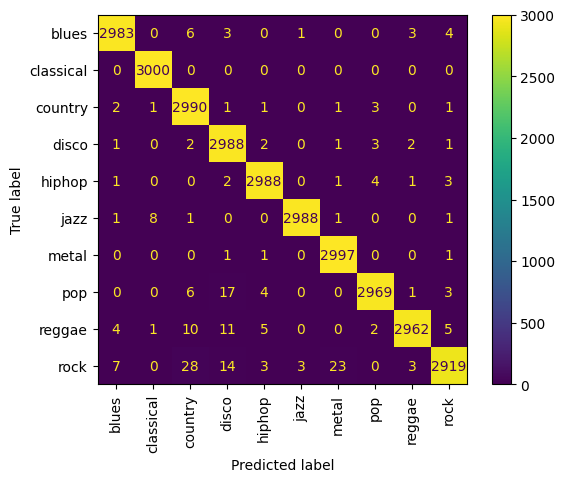

In [16]:
classes = ['blues', 'classical', 'country', 'disco', 'hiphop','jazz', 'metal', 'pop', 'reggae', 'rock'] 
cr = classification_report(idx_to_genre(all_true),idx_to_genre(all_pred),labels=classes)
print(cr)
ConfusionMatrixDisplay.from_predictions(idx_to_genre(all_true),idx_to_genre(all_pred),labels=classes,xticks_rotation='vertical')
plt.show()

# Saving model

In [17]:
model_name = config['model_name']
if os.path.exists(f"/kaggle/working/{model_name}"):
    checkpoint={
        'run_name' : run_name,
        'epoch' : config['epochs'],
        'train_loss' : train_loss,
        'val_loss' : val_loss,
        'f1_score' : f1,
        'model_state_dict' : best_model_state,
        'optimizer_state_dict' : best_optim_state
    }
    torch.save(checkpoint, f"/kaggle/working/{model_name}/checkpoint.pth")
    print(f"✅ {model_name} saved.")
else:
    print(f"Path not exists.")

✅ clstm saved.


# Uploading to KaggleHub

In [18]:
import kagglehub

# Replace with path to directory containing model files.
model_name = config['model_name']
LOCAL_MODEL_DIR = f'/kaggle/working/{model_name}'

MODEL_SLUG = model_name # Replace with model slug.

# Learn more about naming model variations at
# https://www.kaggle.com/docs/models#name-model.
VARIATION_SLUG = 'default' # Replace with variation slug.

kagglehub.model_upload(
  handle = f"akashkumbhakar/{MODEL_SLUG}/pyTorch/{VARIATION_SLUG}",
  local_model_dir = LOCAL_MODEL_DIR,
  version_notes = '')

Uploading Model https://api.kaggle.com/models/akashkumbhakar/clstm/pyTorch/default ...
Starting upload for file /kaggle/working/clstm/checkpoint.pth


Uploading: 100%|██████████| 7.02M/7.02M [00:01<00:00, 3.97MB/s]

Upload successful: /kaggle/working/clstm/checkpoint.pth (7MB)


Your model instance version has been created.
Files are being processed...
See at: https://api.kaggle.com/models/akashkumbhakar/clstm/pyTorch/default
